# Librairies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import tqdm
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches
import matplotlib.colors as plc
from matplotlib.colors import ListedColormap
import cooler
import string

import sys
sys.path.append('../../py_scripts')

from SPAC_Dataset import dataset

path="/home/amergez/SPA-C/datasets_v2"
ds_path = os.path.join(path, "CHM13.DS")

In [6]:
ds_intra = dataset(
    f"{path}/CHM13/SPA-C_ds/CHM13.IntraFM.5K10S_Q0.hdf5", 
    bin_size=5000, 
    image_size=10, 
    skip_check=True, 
    skip_whole=True,
    skip_dataset=True
)
q95 = ds_intra.get_quantile_diag(.95)
print(q95)
del ds_intra

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/CHM13/SPA-C_ds/CHM13.IntraFM.5K10S_Q0.hdf5 ...
Done ! (0.026s)

Dataset metadata :
	Cool2IntraM_FullMat.creation_date: 09/08/2025-16:19:27
	Cool2IntraM_FullMat.filter: None
	Cool2IntraM_FullMat.version: 1.7.0
	data.type: Intra.FullMat
	dataset: CHM13v2.he_Q0



Fetching diagonals values: 100%|████████████████████████████████████████████████████████████████████████████████████████| 24/24 [01:13<00:00,  3.05s/contig]


31.0


In [7]:
DS = {
    "correct":{"path":f"{path}/CHM13/SPA-C_ds/CHM13v2.IntraFM.5K10S_Q0.hdf5"},
    "inter":{"path":f"{path}/CHM13/SPA-C_ds/CHM13v2.InterFM.5K10S_Q0.hdf5"},
    "inter.eq":{"path":f"{path}/CHM13/SPA-C_ds/CHM13v2.InterFM.5K10S_Q0.EQ.hdf5"},
    "translocations":{"path":f"{path}/CHM13.C2A/SPA-C_ds/CHM13.C2A.IntraFM.5K10S_Q0.hdf5"},
    "deletions":{"path":f"{path}/CHM13.C2B/SPA-C_ds/CHM13.C2B.IntraFM.5K10S_Q0.hdf5"},
    "inversions":{"path":f"{path}/CHM13.C2C/SPA-C_ds/CHM13.C2C.IntraFM.5K10S_Q0.hdf5"}
}

for key, sdict in DS.items():
    _ds = dataset(sdict["path"], bin_size=5000, image_size=10, skip_check=True, skip_whole=True)
    _ds.minmax(max_val=q95)
    DS[key]["ds"] = _ds

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/CHM13/SPA-C_ds/CHM13v2.IntraFM.5K10S_Q0.hdf5 ...
Done ! (6.562s)

Dataset metadata :
	Cool2IntraM_FullMat.creation_date: 09/08/2025-16:19:27
	Cool2IntraM_FullMat.filter: None
	Cool2IntraM_FullMat.version: 1.7.0
	data.type: Intra.FullMat
	dataset: CHM13v2.he_Q0

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/CHM13/SPA-C_ds/CHM13v2.InterFM.5K10S_Q0.hdf5 ...
Done ! (31.243s)

Dataset metadata :
	Cool2InterM_FullMat.creation_date: 09/08/2025-15:12:14
	Cool2InterM_FullMat.filter: None
	Cool2InterM_FullMat.version: 1.7.0
	data.type: Inter.FullMat
	dataset: CHM13v2.he_Q0

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/CHM13/SPA-C_ds/CHM13v2.InterFM.5K10S_Q0.EQ.hdf5 ...
Done ! (1.944s)

Dataset metadata :
	Cool2InterM_FullMat.creation_date: 09/08/2025-15:12:14
	Cool2InterM_FullMat.filter: None
	Cool2InterM_FullMat.version: 1.7.0
	Edit: Modified with DLScaffDataset v5.7
	data.type: Inter.FullMat
	dataset

# Figures

## Distributions

In [8]:
# sumsPerMatrices = np.sum(np.sum(self.dataset["x"], axis = 2), axis = 1)

fig, axs = plt.subplots(6, 1, figsize = (12, 2.5*6), dpi = 600, sharey=True, sharex=True)
fs = 10
plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})

labels = {
    "correct": "Join (correct) samples*",
    "inter": "Inter samples (raw)",
    "inter.eq": "Inter samples (sub-sampled)*",
    "translocations": "Synthetic translocations samples*",
    "deletions": "Synthetic deletions samples*",
    "inversions": "Synthetic inversions samples*",
}

for i, key in enumerate(DS.keys()):
    cum_sums = np.sum(DS[key]["ds"].dataset["x"], axis = (1,2))
    axs[i].hist(cum_sums, bins = 100, log=True)
    axs[i].spines["right"].set_visible(False)
    axs[i].spines["top"].set_visible(False)
    if i != len(DS)-1:
        axs[i].tick_params(
            axis='both',          
            which='both',         
            bottom=True,         
            top=False,            
            left=True,           
            right=False,          
            labelbottom=True,    
            labeltop=False,       
            labelleft=True,      
            labelright=False      
        )
    else:
        axs[i].set_xlabel("Total number of contacts in matrix")
    axs[i].set_ylabel("Count")

    axs[i].annotate(
            list(string.ascii_uppercase)[i],
            xy=(-0.1, 1.1),
            xycoords="axes fraction",
            fontsize=fs,
            fontweight="bold",
            color="black",
            va="top",
            ha="left",
        )
    
    axs[i].set_title(labels[key], fontsize=fs)

plt.tight_layout()
plt.savefig("SUPP.PAPER.CHM13_stats.png")
plt.show()

## Gap lengths

In [9]:
def get_features(name):
    ctg1_chrom, ctg1_start, ctg1_end, ctg2_chrom, ctg2_start, ctg2_end, binid, corner = re.split(r"\||-|:|_", name)
    return ctg1_chrom, int(ctg1_start), int(ctg1_end), ctg2_chrom, int(ctg2_start), int(ctg2_end)

In [10]:
# Computing distance between middle position of each pairs of contigs
gap_sizes = {
    str(name) : np.mean(get_features(name)[4:6]) - np.mean(get_features(name)[1:3])
    for name in DS["deletions"]["ds"].dataset["names"]
}
gaps = np.array(list(gap_sizes.values()))

# Ajdusting to get the gap between both ends of contigs
gaps += np.array([(1 if k<0 else -1)*100000 for k in gaps])

In [11]:
k=1000
DS["deletions"]["ds"].dataset["names"][k:k+10]

array(['chr8:45900000-46000000|chr8:42200000-42300000_20_C2',
       'chr8:45900000-46000000|chr8:42200000-42300000_20_C3',
       'chr8:45900000-46000000|chr8:42200000-42300000_21_C2',
       'chr8:45900000-46000000|chr8:42200000-42300000_21_C3',
       'chr8:45900000-46000000|chr8:42200000-42300000_22_C2',
       'chr8:45900000-46000000|chr8:42200000-42300000_22_C3',
       'chr8:45900000-46000000|chr8:42200000-42300000_23_C2',
       'chr8:45900000-46000000|chr8:42200000-42300000_23_C3',
       'chr21:44500000-44600000|chr21:43800000-43900000_17_C2',
       'chr21:44500000-44600000|chr21:43800000-43900000_17_C3'],
      dtype='<U57')

In [12]:
gaps/1000000

array([0.2, 0.2, 0.2, ..., 2.8, 2.8, 2.8])

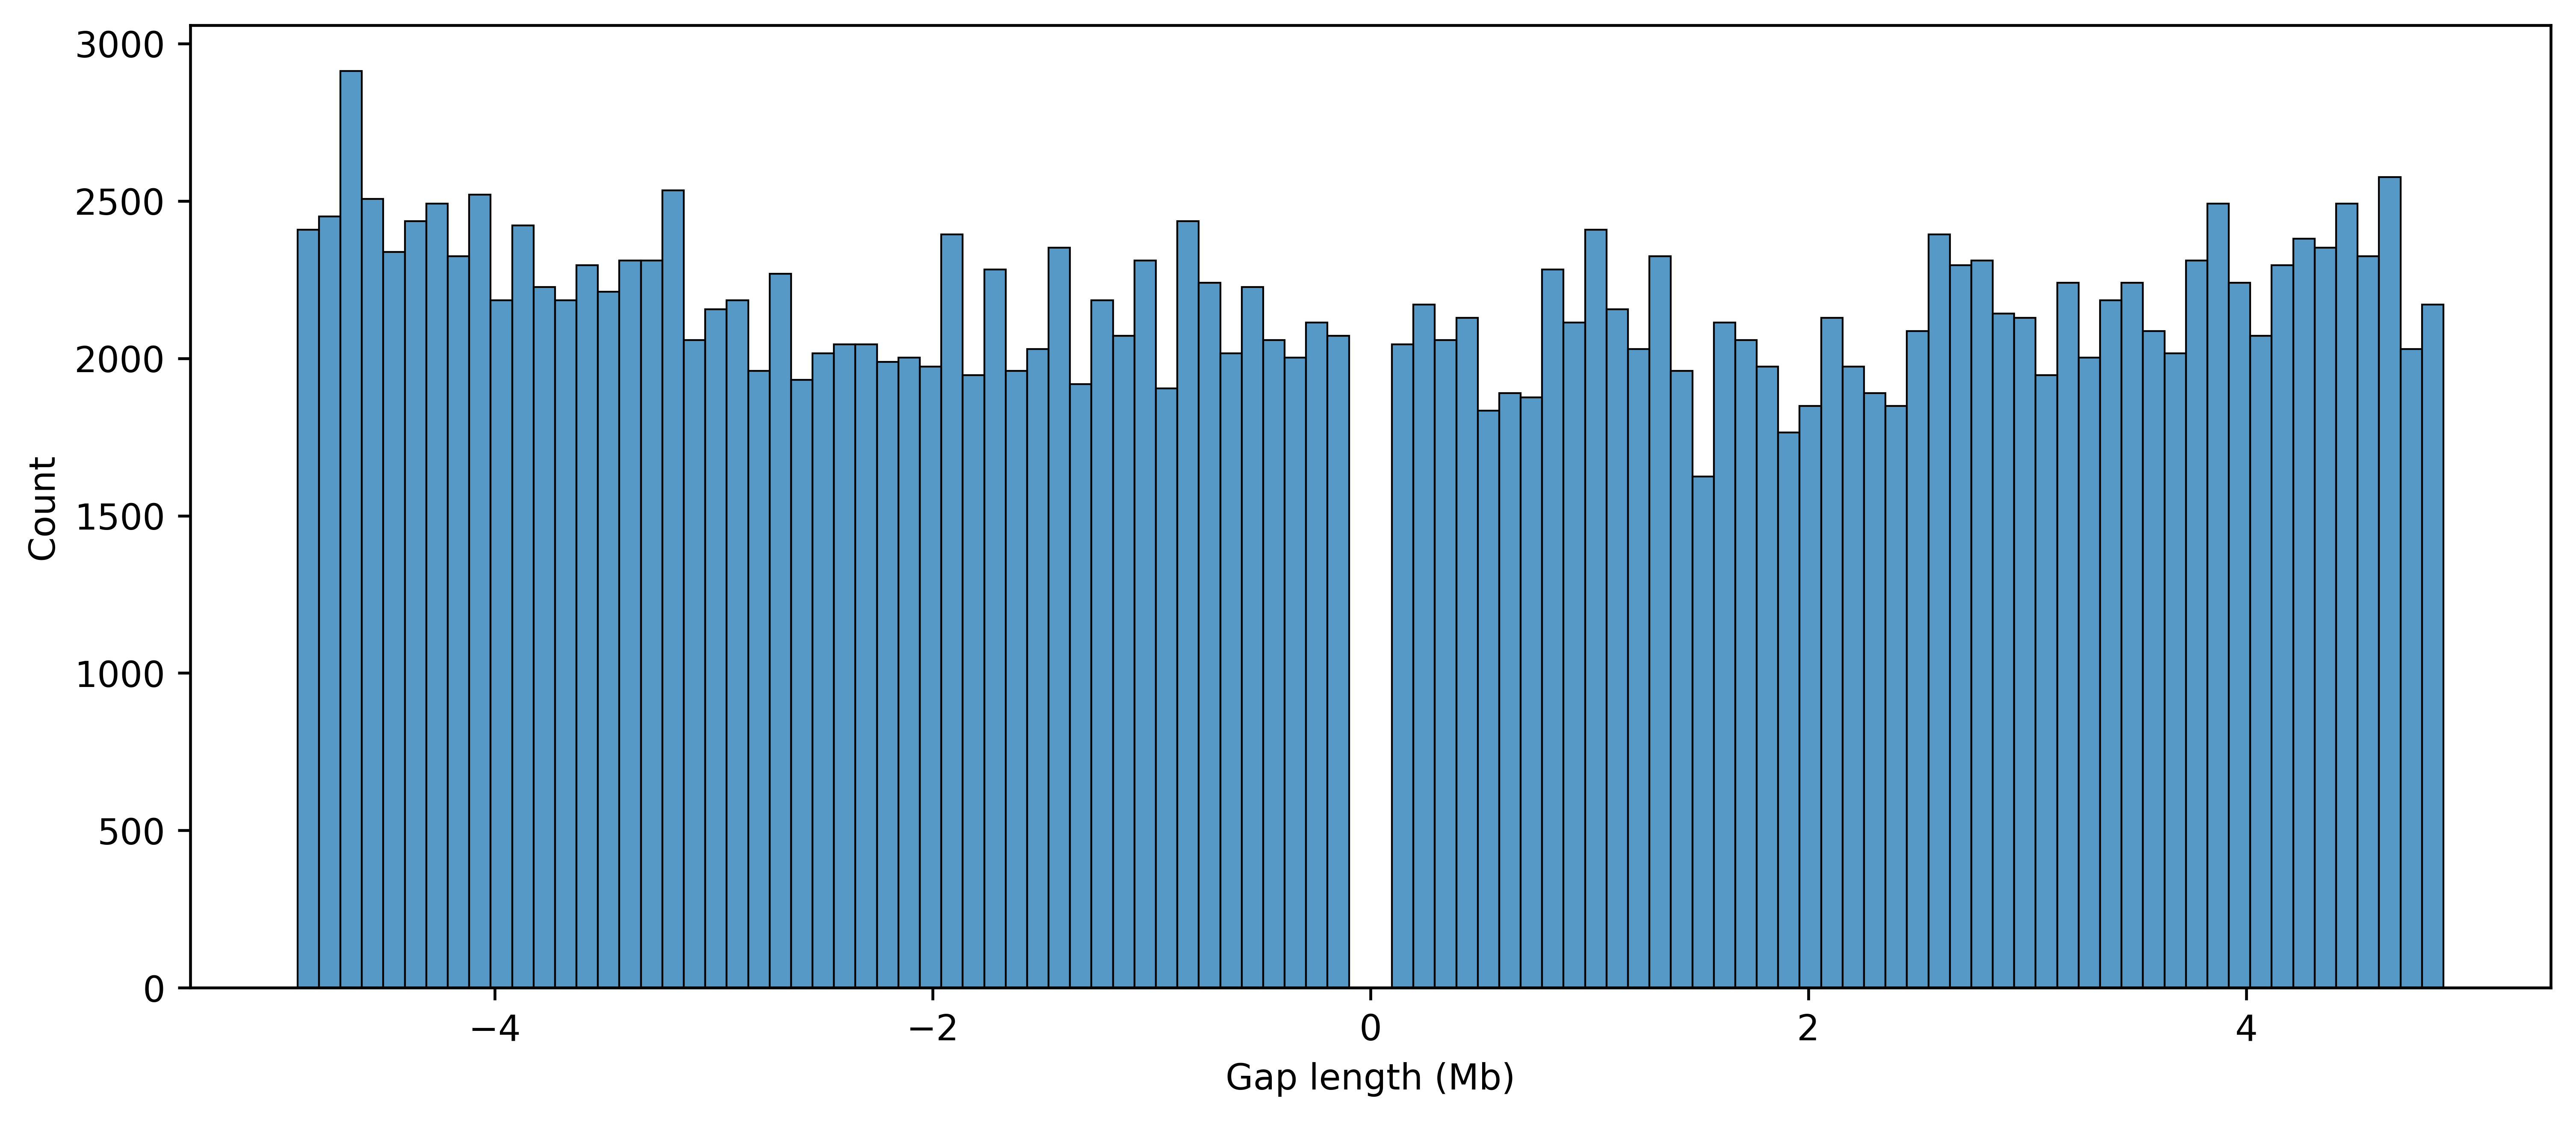

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10,5), dpi=600)
fs = 10
plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})


sns.histplot(gaps/1000000, bins=100, ax=ax)
ax.set_xlabel("Gap length (Mb)")
#ax.set_title(
#    "Gap length distribution between left and right regions of chimeric contigs",
#    size=fs
#)
fig.subplots_adjust(bottom=0.2, top=0.95, left=0.07, right=0.99)
#fig.text(
#    0.99, 
#    0.04, 
#    "Each contig has a fixed length and is composed of two equally sized regions (left and right).\nA negative gap size indicates that the left region is positioned further along the chromosome than the right region.", 
#    ha='right',
#    fontstyle="italic"
#)

#plt.tight_layout()
plt.savefig("SUPP.PAPER.CHM13_gap.png")
plt.show(fig)
#plt.close()